In [ ]:
import os
import time
from datetime import datetime
import pandas as pd
import requests

SCOREBOARD_URL = "https://site.api.espn.com/apis/site/v2/sports/basketball/mens-college-basketball/scoreboard"
PBP_URL = "https://site.api.espn.com/apis/site/v2/sports/basketball/mens-college-basketball/summary"

OUT_CSV = "cbb_pbp.csv"
date = "20260227" # Use YYYYMMDD format. Change to desired date

def get_scoreboard_game_ids(date_yyyymmdd: str, group: str = "50", timeout=15) -> list[str]:
    r = requests.get(
        SCOREBOARD_URL,
        params={"dates": date_yyyymmdd, "groups": group, "limit": 500, "offset": 0},
        timeout=timeout,
    )
    r.raise_for_status()
    data = r.json()
    events = data.get("events", []) or []
    return [str(e.get("id")) for e in events if e.get("id")]

def fetch_pbp(game_id: str, timeout=20) -> dict:
    r = requests.get(PBP_URL, params={"event": game_id}, timeout=timeout)
    r.raise_for_status()
    return r.json()

def extract_player_from_text(text: str, action: str) -> str:
    """
    Extract player names from play text for assist, rebound, or score actions.
    Returns player name or empty string if not found.
    """
    if not text:
        return ""
    
    import re
    
    # Score: Everything before "makes" or "made"
    if action == "score":
        match = re.match(r"^(.+?)\s+makes?\b", text, re.IGNORECASE)
        if match:
            return match.group(1).strip()
    
    # Miss: Everything before "misses"
    elif action == "miss":
        match = re.match(r"^(.+?)\s+misses?\b", text, re.IGNORECASE)
        if match:
            return match.group(1).strip()
    
    # Rebound: "Player Name Rebound" (without offense/defense qualifiers)
    elif action == "rebound":
        if "rebound" in text.lower():
            # Extract name before "Rebound", removing offensive/defensive qualifier
            match = re.match(r"([^(]+?)\s+(?:Offensive|Defensive)?\s*Rebound", text, re.IGNORECASE)
            if match:
                name = match.group(1).strip()
                # Remove offensive/defensive from the name if it got included
                name = re.sub(r"\s+(?:Offensive|Defensive)$", "", name, flags=re.IGNORECASE)
                return name
    
    # Assist: Everything in parenthesis before "assists"
    elif action == "assist":
        if "assist" in text.lower():
            # Extract what's in parenthesis before "assists"
            match = re.search(r"\((.+?)\s+assists?\)", text, re.IGNORECASE)
            if match:
                return match.group(1).strip()
    
    return ""

def extract_rebound_type(text: str) -> str:
    """
    Extract rebound type (Offensive or Defensive).
    Returns 'Offensive', 'Defensive', or empty string.
    """
    if not text or "rebound" not in text.lower():
        return ""
    
    import re
    
    match = re.search(r"(Offensive|Defensive)\s+Rebound", text, re.IGNORECASE)
    if match:
        return match.group(1)
    return ""

def flatten_plays(game_id: str, pbp_json: dict) -> pd.DataFrame:
    """
    ESPN pbp response typically has a 'plays' list.
    This flattens common fields. Any missing values become blank/NaN.
    """
    plays = pbp_json.get("plays", []) or []
    rows = []
    
    # Extract home and away team info once for the entire game
    home_team = None
    away_team = None
    team_id_to_name = {}
    
    boxscore = pbp_json.get("boxscore", {})
    teams = boxscore.get("teams", [])
    
    # Get team names and IDs from boxscore teams with homeAway designation
    for team in teams:
        team_info = team.get("team", {})
        team_name = team_info.get("location") or team_info.get("name")
        team_id = team_info.get("id")
        home_away = team.get("homeAway", "").lower()
        
        if home_away == "home":
            home_team = team_name
            if team_id:
                team_id_to_name[str(team_id)] = team_name
        elif home_away == "away":
            away_team = team_name
            if team_id:
                team_id_to_name[str(team_id)] = team_name

    for play_num, p in enumerate(plays, start=1):
        period = p.get("period", {}).get("number") if isinstance(p.get("period"), dict) else p.get("period")
        clock = p.get("clock", {}).get("displayValue") if isinstance(p.get("clock"), dict) else p.get("clock")
        text = p.get("text")
        home_score = p.get("homeScore")
        away_score = p.get("awayScore")

        # Get team_id from play
        team_id = None
        if isinstance(p.get("team"), dict):
            team_id = p["team"].get("id")
        
        # Map team_id to team name using our lookup
        team = team_id_to_name.get(str(team_id)) if team_id else None

        # Some play entries include a type
        play_type = None
        play_type_id = None
        if isinstance(p.get("type"), dict):
            play_type = p["type"].get("text")
            play_type_id = p["type"].get("id")

        # Extract player actions from text
        scorer = extract_player_from_text(text, "score") if p.get("scoreValue") else ""
        missser = extract_player_from_text(text, "miss") if "miss" in (text or "").lower() else ""
        rebounder = extract_player_from_text(text, "rebound") if "rebound" in (text or "").lower() else ""
        rebound_type = extract_rebound_type(text) if "rebound" in (text or "").lower() else ""
        assister = extract_player_from_text(text, "assist") if "assist" in (text or "").lower() else ""

        # Extract shooter/player coordinates from the play
        coord = p.get("coordinate", {})
        coord_x = coord.get("x") if isinstance(coord, dict) else None
        coord_y = coord.get("y") if isinstance(coord, dict) else None

        rows.append({
            "game_id": game_id,
            "play_number": play_num,
            "period": period,
            "clock": clock,
            "text": text,
            "home_team": home_team,
            "away_team": away_team,
            "home_score": home_score,
            "away_score": away_score,
            "team_id": team_id,
            "team": team,
            "play_type_id": play_type_id,
            "play_type": play_type,
            "score": scorer,
            "miss": missser,
            "assist": assister,
            "rebound": rebounder,
            "rebound_type": rebound_type,
            "coord_x": coord_x,
            "coord_y": coord_y,
            "wallclock": p.get("wallclock") or p.get("startTime") or None,
        })

    return pd.DataFrame(rows)

def append_df_to_csv(df: pd.DataFrame, path: str):
    write_header = not os.path.exists(path)
    df.to_csv(path, mode="a", header=write_header, index=False)

def run(date_yyyymmdd: str, group: str = "50", sleep_s: float = 0.25):
    game_ids = get_scoreboard_game_ids(date_yyyymmdd, group=group)
    print(f"Found {len(game_ids)} games for {date_yyyymmdd} (groups={group})")

    for i, game_id in enumerate(game_ids, start=1):
        try:
            pbp_json = fetch_pbp(game_id)
            df = flatten_plays(game_id, pbp_json)
            if not df.empty:
                append_df_to_csv(df, OUT_CSV)
            print(f"[{i}/{len(game_ids)}] saved {len(df)} plays for game_id={game_id}")
        except requests.RequestException as e:
            print(f"[{i}/{len(game_ids)}] ERROR game_id={game_id}: {e}")
        time.sleep(sleep_s)

if __name__ == "__main__":
    run(date, group="50")

Found 21 games for 20260227 (groups=50)
[1/21] saved 422 plays for game_id=401825544
[2/21] saved 454 plays for game_id=401814590
[3/21] saved 430 plays for game_id=401818335
[4/21] saved 473 plays for game_id=401813395
[5/21] saved 457 plays for game_id=401828448
[6/21] saved 487 plays for game_id=401823856
[7/21] saved 467 plays for game_id=401818546
[8/21] saved 397 plays for game_id=401813432
[9/21] saved 448 plays for game_id=401813418
[10/21] saved 378 plays for game_id=401813371
[11/21] saved 448 plays for game_id=401813318
[12/21] saved 357 plays for game_id=401812623
[13/21] saved 544 plays for game_id=401812596
[14/21] saved 389 plays for game_id=401808700
[15/21] saved 490 plays for game_id=401808694
[16/21] saved 466 plays for game_id=401814586
[17/21] saved 390 plays for game_id=401808697
[18/21] saved 436 plays for game_id=401808695
[19/21] saved 369 plays for game_id=401808699
[20/21] saved 409 plays for game_id=401808696
[21/21] saved 523 plays for game_id=401808698


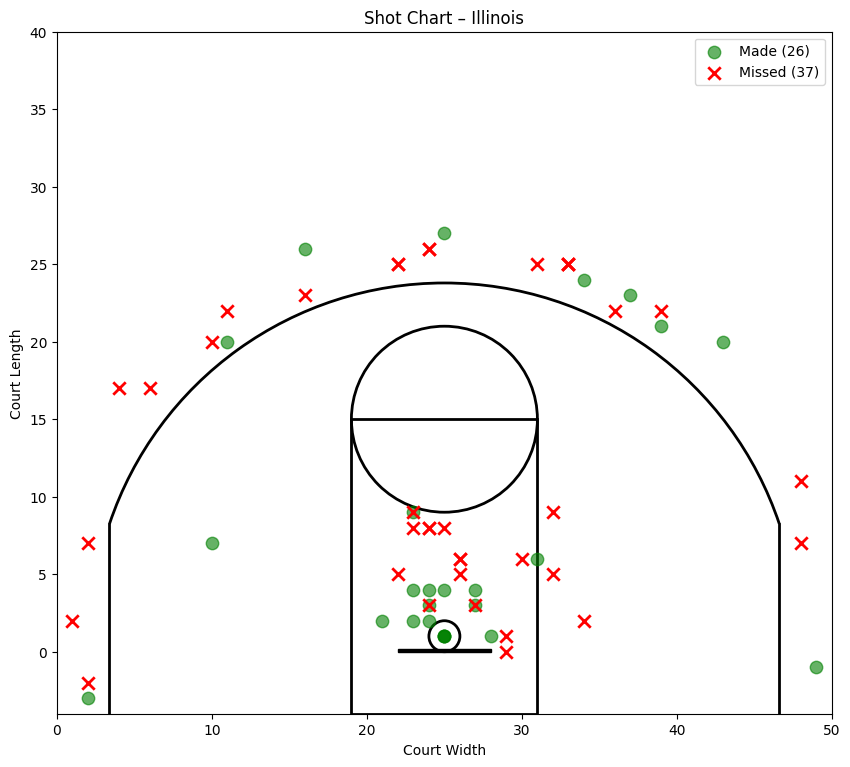

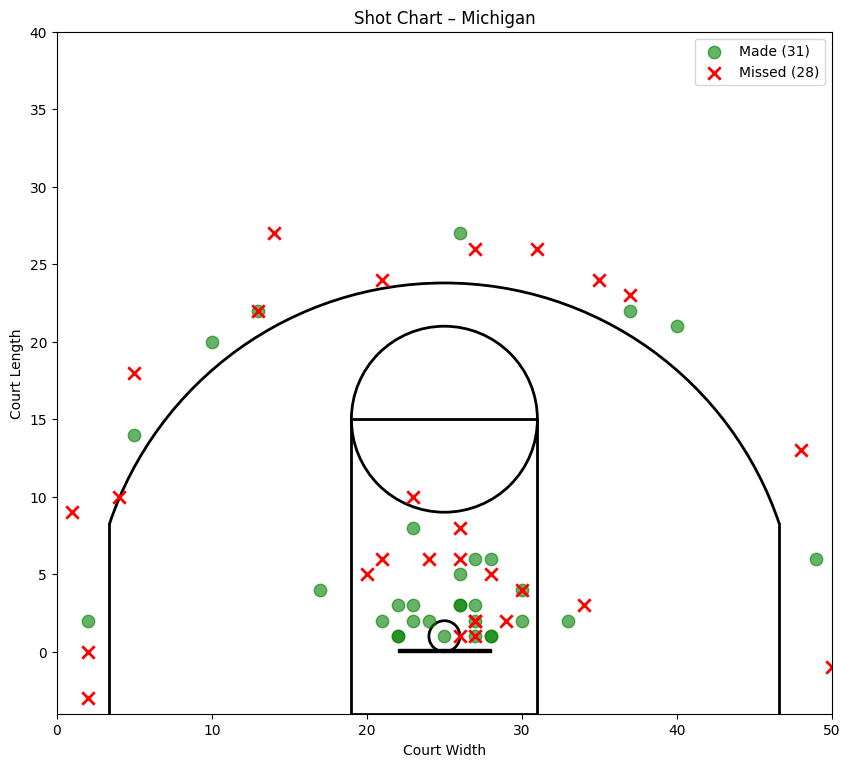

In [60]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np
from matplotlib.patches import Rectangle, Circle, Arc

# Load CSV
csv_path = os.path.join(os.path.dirname(os.path.abspath('cbb_pbp.csv')), 'cbb_pbp.csv')
if not os.path.exists(csv_path):
    csv_path = 'cbb_pbp.csv'

df = pd.read_csv(csv_path)
game_id = 401825544

# Filter for specific game
game_df = df[df['game_id'] == game_id]

# Shot types
shot_types = ['DunkShot', 'JumpShot', 'LayUpShot', 'TipShot']
shots = game_df[game_df['play_type'].isin(shot_types)]

if len(game_df) == 0:
    print(f"No data found for game_id {game_id}")

elif len(shots) == 0:
    print(f"No shots found for game_id {game_id}")

else:
    home_team = game_df['home_team'].iloc[0]
    away_team = game_df['away_team'].iloc[0]

    # Map team_id to team_name
    team_id_map = {}
    unique_ids = game_df['team_id'].dropna().unique()

    if len(unique_ids) == 2:
        team_id_map[unique_ids[0]] = home_team
        team_id_map[unique_ids[1]] = away_team

    team_ids = shots['team_id'].unique()

    def draw_court(ax):
        court_width = 50
        hoop_x, hoop_y = 25, 1

        # Hoop
        hoop = Circle((hoop_x, hoop_y), 1, color='black', fill=False, linewidth=2)
        backboard = Rectangle((hoop_x - 3, hoop_y - 1), 6, 0.15, color='black')
        ax.add_patch(hoop)
        ax.add_patch(backboard)

        # Paint (centered at hoop)
        paint = Rectangle((19, -4), 12, 19, fill=False, linewidth=2)
        ax.add_patch(paint)

        # Free throw circle
        ft_circle = Circle((hoop_x, 15), 6, fill=False, linewidth=2)
        ax.add_patch(ft_circle)

        # 3PT parameters
        three_pt_radius = 22.79
        y_cutoff = 8.25

        # Compute cutoff angle
        theta_cutoff = np.degrees(
            np.arcsin((y_cutoff - hoop_y) / three_pt_radius)
        )

        # 3PT arc (trimmed above y=8.25)
        three_pt_arc = Arc(
            (hoop_x, hoop_y),
            2 * three_pt_radius,
            2 * three_pt_radius,
            angle=0,
            theta1=theta_cutoff,
            theta2=180 - theta_cutoff,
            linewidth=2
        )
        ax.add_patch(three_pt_arc)

        # Corner 3PT lines
        ax.plot([3.39, 3.39], [-4, 8.25], color='black', linewidth=2)
        ax.plot([46.61, 46.61], [-4, 8.25], color='black', linewidth=2)

    for team_id in team_ids:
        if pd.isna(team_id):
            continue

        team_shots = shots[shots['team_id'] == team_id]
        team_name = team_id_map.get(team_id, "Unknown")

        fig, ax = plt.subplots(figsize=(10, 11))
        draw_court(ax)

        # Made shots
        made = team_shots[team_shots['score'].notna()]
        ax.scatter(
            made['coord_x'],
            made['coord_y'],
            c='green',
            s=80,
            alpha=0.6,
            label=f'Made ({len(made)})'
        )

        # Missed shots
        missed = team_shots[team_shots['score'].isna()]
        ax.scatter(
            missed['coord_x'],
            missed['coord_y'],
            c='red',
            s=80,
            marker='x',
            linewidths=2,
            label=f'Missed ({len(missed)})'
        )

        ax.set_xlim(0, 50)
        ax.set_ylim(-4, 40)
        ax.set_aspect('equal')
        ax.set_xlabel('Court Width')
        ax.set_ylabel('Court Length')
        ax.set_title(f'Shot Chart – {team_name}')
        ax.legend()

        plt.show()